# Neural Network — Fetal Health Classification

We train `rice_ml.MLPClassifier` on all three fetal-health
classes (Normal, Suspect, Pathological) using the 21 CTG
features. The network uses ReLU hidden layers and a softmax
output trained with mini-batch SGD and cross-entropy.

$$a^{(0)} = x,\quad z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)},\quad a^{(\ell)} = \sigma(z^{(\ell)})$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.pre_processing import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.supervised_learning.multilayer_perceptron import MLPClassifier
from rice_ml.processing.pre_processing import StandardScaler, train_test_split
from rice_ml.processing.post_processing import accuracy_score, confusion_matrix

df = pd.read_csv(find_data_file("fetal_health.csv"))
X = df.drop(columns=["fetal_health"]).to_numpy(dtype=float)
y = df["fetal_health"].to_numpy(dtype=int)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

In [3]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    learning_rate=0.05, max_iter=120, batch_size=64,
    alpha=1e-4, random_state=0,
).fit(X_tr_s, y_tr)
y_pred = mlp.predict(X_te_s)
print(f"Test accuracy = {accuracy_score(y_te, y_pred):.4f}")

labels = [1, 2, 3]
cm = confusion_matrix(y_te, y_pred, labels=labels)
pd.DataFrame(
    cm,
    index=["true " + str(i) for i in labels],
    columns=["pred " + str(i) for i in labels],
)

Test accuracy = 0.9229


,pred 1,pred 2,pred 3
true 1,400,12,2
true 2,15,59,0
true 3,6,6,32


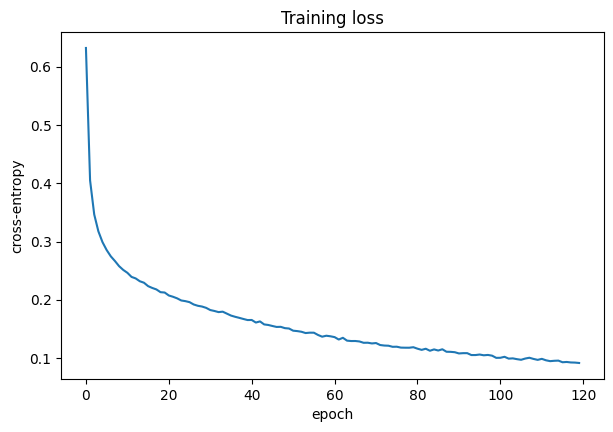

In [4]:
fig, ax = plt.subplots()
ax.plot(mlp.loss_history_)
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_title("Training loss")
plt.show()

## Takeaways

- Non-linear boundaries help when classes overlap in the
  original feature space.
- Watch the loss curve for under- or over-training; adjust
  `max_iter` or `learning_rate` if needed.
- Confusion matrices show whether Suspect is confused with
  Normal — often the clinically important error mode.